# CTable Tutorial

**CTable** is a columnar compressed table built on top of `blosc2.NDArray`.  
It stores each column independently as a compressed array, giving you:

- **Compression** — data lives compressed in RAM and on disk.
- **Schema** — every column has a declared type and optional constraints.
- **Speed** — bulk operations stay in NumPy; no row-by-row Python overhead.
- **Persistence** — tables can be saved to and loaded from disk transparently.

This notebook walks through the full API, starting from the very basics and finishing with a real-world analysis of climate data across ten world cities.

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

import blosc2
from blosc2 import CTable

---
## Part 1 — The Basics

### 1.1 Defining a schema

Every CTable is typed.  You define the schema with a plain Python `@dataclass`.
Each field gets a **spec** — a blosc2 type that carries the NumPy dtype and optional constraints.

In [2]:
@dataclass
class Sensor:
    id: int = blosc2.field(blosc2.int32(ge=0))
    location: str = blosc2.field(blosc2.string(max_length=16), default="")
    temperature: float = blosc2.field(blosc2.float64(ge=-80, le=60), default=20.0)
    active: bool = blosc2.field(blosc2.bool(), default=True)


# Create an empty in-memory table
t = CTable(Sensor, expected_size=50)
print(f"Empty table: {len(t)} rows, columns: {t.col_names}")

Empty table: 0 rows, columns: ['id', 'location', 'temperature', 'active']


### 1.2 Appending rows

`append()` adds one row at a time.  The row is validated against the schema before writing.

In [3]:
t.append(Sensor(id=0, location="roof", temperature=22.5, active=True))
t.append(Sensor(id=1, location="basement", temperature=18.1, active=True))
t.append(Sensor(id=2, location="outdoor", temperature=-3.2, active=False))
print(t)

 id            location            temperature        active 
 int32         <U16                float64            bool   
────────────  ──────────────────  ─────────────────  ────────
 0             roof                22.5               True   
 1             basement            18.1               True   
 2             outdoor             -3.2               False  
────────────  ──────────────────  ─────────────────  ────────
3 rows × 4 columns


Constraints are enforced — trying to insert a temperature above 60 °C raises an error:

In [4]:
try:
    t.append(Sensor(id=99, location="sun", temperature=9999.0, active=True))
except Exception as e:
    print(f"Validation error: {e}")

Validation error: 1 validation error for _Validator_Sensor
temperature
  Input should be less than or equal to 60 [type=less_than_equal, input_value=9999.0, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal


### 1.3 Bulk loading with `extend()`

`extend()` accepts a list of tuples or a structured NumPy array.  
It is **much faster** than calling `append()` in a loop.

In [5]:
bulk = [
    (3, "lab-A", 20.0, True),
    (4, "lab-B", 21.5, True),
    (5, "server", 35.8, True),
    (6, "garden", -1.0, False),
]
t.extend(bulk)
print(f"After extend: {len(t)} rows")
print(t)

After extend: 7 rows
 id            location            temperature        active 
 int32         <U16                float64            bool   
────────────  ──────────────────  ─────────────────  ────────
 0             roof                22.5               True   
 1             basement            18.1               True   
 2             outdoor             -3.2               False  
 3             lab-A               20.0               True   
 4             lab-B               21.5               True   
 5             server              35.8               True   
 6             garden              -1.0               False  
────────────  ──────────────────  ─────────────────  ────────
7 rows × 4 columns


### 1.4 Navigating the table

`head()`, `tail()`, and slicing give you quick views without materialising everything.

In [6]:
print("--- head(3) ---")
print(t.head(3))

print("--- tail(2) ---")
print(t.tail(2))

print(f"\nCompression: {t.cbytes:,} B compressed / {t.nbytes:,} B uncompressed")

--- head(3) ---
 id            location            temperature        active 
 int32         <U16                float64            bool   
────────────  ──────────────────  ─────────────────  ────────
 0             roof                22.5               True   
 1             basement            18.1               True   
 2             outdoor             -3.2               False  
────────────  ──────────────────  ─────────────────  ────────
3 rows × 4 columns
--- tail(2) ---
 id            location            temperature        active 
 int32         <U16                float64            bool   
────────────  ──────────────────  ─────────────────  ────────
 5             server              35.8               True   
 6             garden              -1.0               False  
────────────  ──────────────────  ─────────────────  ────────
2 rows × 4 columns

Compression: 747 B compressed / 3,900 B uncompressed


### 1.5 Columns as first-class objects

Access a column with `table["name"]` or `table.name`.  
Columns are lazy — they only decompress data when you ask for it.

In [7]:
temps = t["temperature"]
print(f"dtype  : {temps.dtype}")
print(f"min    : {temps.min():.1f} °C")
print(f"max    : {temps.max():.1f} °C")
print(f"mean   : {temps.mean():.1f} °C")
print(f"as numpy: {temps.to_numpy()}")

dtype  : float64
min    : -3.2 °C
max    : 35.8 °C
mean   : 16.2 °C
as numpy: [22.5 18.1 -3.2 20.  21.5 35.8 -1. ]


---
## Part 2 — The Climate Dataset

Enough warm-up. Let's do something real.

We will simulate **one full year of daily weather readings** for **10 world cities**.  
Each row is one day at one city: temperature, humidity, wind speed, atmospheric pressure.

| City | Climate | Twist |
|------|---------|-------|
| Madrid | Mediterranean | Scorching summers, mild winters |
| London | Temperate oceanic | Famously grey and damp |
| Beijing | Continental | Brutal winters, hot summers |
| New York | Humid continental | Four very distinct seasons |
| Tokyo | Humid subtropical | Warm and very humid summers |
| Sydney | Oceanic (S. hemisphere) | Seasons are flipped! |
| Cairo | Hot desert | Basically always hot |
| Moscow | Subarctic | Coldest city in the dataset |
| Mumbai | Tropical | Hot and humid all year |
| São Paulo | Tropical highland | Warm, rainy, south hemisphere |

In [8]:
@dataclass
class WeatherReading:
    city: str = blosc2.field(blosc2.string(max_length=16))
    day: int = blosc2.field(blosc2.int16(ge=1, le=365), default=1)
    temperature: float = blosc2.field(blosc2.float32(ge=-80.0, le=60.0), default=20.0)
    humidity: float = blosc2.field(blosc2.float32(ge=0.0, le=100.0), default=50.0)
    wind_speed: float = blosc2.field(blosc2.float32(ge=0.0, le=200.0), default=0.0)
    pressure: float = blosc2.field(blosc2.float32(ge=800.0, le=1100.0), default=1013.0)

In [9]:
# Climate profile for each city:
#   mean_temp  : annual mean temperature (°C)
#   amplitude  : half the annual temperature swing (°C)
#   peak_day   : day of year with the highest temperature
#                (196 ≈ July 15 for N. hemisphere, 15 ≈ Jan 15 for S. hemisphere)
#   humidity   : annual mean relative humidity (%)
#   wind       : mean wind speed (km/h)
#   pressure   : mean atmospheric pressure (hPa)

CITY_PROFILES = {
    "Madrid": {
        "mean_temp": 15.0,
        "amplitude": 13.0,
        "peak_day": 196,
        "humidity": 45,
        "wind": 12,
        "pressure": 1010,
    },
    "London": {
        "mean_temp": 11.0,
        "amplitude": 7.0,
        "peak_day": 196,
        "humidity": 75,
        "wind": 15,
        "pressure": 1013,
    },
    "Beijing": {
        "mean_temp": 12.0,
        "amplitude": 16.0,
        "peak_day": 196,
        "humidity": 55,
        "wind": 10,
        "pressure": 1012,
    },
    "New York": {
        "mean_temp": 13.0,
        "amplitude": 14.0,
        "peak_day": 196,
        "humidity": 65,
        "wind": 14,
        "pressure": 1013,
    },
    "Tokyo": {
        "mean_temp": 15.0,
        "amplitude": 12.0,
        "peak_day": 196,
        "humidity": 72,
        "wind": 11,
        "pressure": 1014,
    },
    "Sydney": {
        "mean_temp": 18.0,
        "amplitude": 8.0,
        "peak_day": 15,
        "humidity": 65,
        "wind": 16,
        "pressure": 1012,
    },
    "Cairo": {
        "mean_temp": 22.0,
        "amplitude": 14.0,
        "peak_day": 196,
        "humidity": 35,
        "wind": 8,
        "pressure": 1014,
    },
    "Moscow": {
        "mean_temp": 5.0,
        "amplitude": 18.0,
        "peak_day": 196,
        "humidity": 70,
        "wind": 10,
        "pressure": 1015,
    },
    "Mumbai": {
        "mean_temp": 28.0,
        "amplitude": 4.0,
        "peak_day": 196,
        "humidity": 80,
        "wind": 12,
        "pressure": 1011,
    },
    "Sao Paulo": {
        "mean_temp": 22.0,
        "amplitude": 5.0,
        "peak_day": 15,
        "humidity": 75,
        "wind": 8,
        "pressure": 1016,
    },
}

rng = np.random.default_rng(42)
days = np.arange(1, 366, dtype=np.int16)

all_rows = []
for city, p in CITY_PROFILES.items():
    seasonal = p["amplitude"] * np.cos(2 * np.pi * (days - p["peak_day"]) / 365)
    temps = (p["mean_temp"] + seasonal + rng.normal(0, 2.0, 365)).clip(-80, 60).astype(np.float32)
    humidity = (p["humidity"] + rng.normal(0, 8.0, 365)).clip(0, 100).astype(np.float32)
    wind = (p["wind"] + rng.exponential(4.0, 365)).clip(0, 200).astype(np.float32)
    pressure = (p["pressure"] + rng.normal(0, 5.0, 365)).clip(800, 1100).astype(np.float32)
    for i, d in enumerate(days):
        all_rows.append(
            (city, int(d), float(temps[i]), float(humidity[i]), float(wind[i]), float(pressure[i]))
        )

climate = CTable(WeatherReading, new_data=all_rows, validate=False, expected_size=len(all_rows))
print(f"Climate table: {len(climate):,} rows × {climate.ncols} columns")
print(f"Compressed: {climate.cbytes / 1024:.1f} KB  (uncompressed: {climate.nbytes / 1024:.1f} KB)")
print(climate)

Climate table: 3,650 rows × 6 columns
Compressed: 42.1 KB  (uncompressed: 295.8 KB)
 city                day         temperature     humidity        wind_speed      pressure     
 <U16                int16       float32         float32         float32         float32      
──────────────────  ──────────  ──────────────  ──────────────  ──────────────  ──────────────
 Madrid              1           2.909233808517456    56.85164260864258    14.764506340026855    1014.2011108398438 
 Madrid              2           0.17393270134925842    39.051292419433594    12.571674346923828    1017.43701171875 
 Madrid              3           3.712681531906128    38.422000885009766    12.351028442382812    1008.6416015625 
 Madrid              4           4.054576396942139    46.61845016479492    14.6717529296875    1004.23876953125 
 Madrid              5           -1.7631549835205078    51.75508117675781    18.27811622619629    1008.7977905273438 
 Madrid              6           -0.49616417288780

---
## Part 3 — Querying

### 3.1 Filtering rows with `where()`

`where()` takes a boolean expression built from column comparisons and returns a **view** —  
a lightweight object that shares the underlying data without copying it.

In [10]:
# All days where temperature exceeded 35 °C (any city)
very_hot = climate.where(climate["temperature"] > 35)
print(f"Days above 35 °C: {len(very_hot)} ({len(very_hot) / len(climate) * 100:.1f}% of all readings)")
print(very_hot.head(8))

Days above 35 °C: 49 (1.3% of all readings)
 city                day         temperature     humidity        wind_speed      pressure     
 <U16                int16       float32         float32         float32         float32      
──────────────────  ──────────  ──────────────  ──────────────  ──────────────  ──────────────
 Cairo               154         35.72507095336914    39.59734344482422    10.807509422302246    1010.431884765625 
 Cairo               157         35.6644172668457    38.082462310791016    9.141173362731934    1016.99755859375 
 Cairo               158         35.808841705322266    34.47190475463867    12.61370849609375    1016.7548828125 
 Cairo               162         35.91463088989258    33.7704963684082    20.62659454345703    1008.7472534179688 
 Cairo               163         36.98370361328125    31.699254989624023    15.528841972351074    1010.4817504882812 
 Cairo               165         37.557411193847656    35.598121643066406    9.19057846069336 

In [11]:
# Moscow in winter (below freezing)
moscow_frozen = climate.where((climate["city"] == "Moscow") & (climate["temperature"] < 0))
print(f"Moscow below freezing: {len(moscow_frozen)} days out of 365")
print(moscow_frozen.head())

Moscow below freezing: 148 days out of 365
 city                day         temperature     humidity        wind_speed      pressure     
 <U16                int16       float32         float32         float32         float32      
──────────────────  ──────────  ──────────────  ──────────────  ──────────────  ──────────────
 Moscow              1           -13.509984970092773    76.91526794433594    10.18380069732666    1006.7850952148438 
 Moscow              2           -13.053152084350586    77.78500366210938    20.356876373291016    1010.10107421875 
 Moscow              3           -12.944221496582031    81.18754577636719    16.775102615356445    1020.9932861328125 
 Moscow              4           -12.862519264221191    73.40472412109375    13.4474458694458    1013.95703125 
 Moscow              5           -10.471738815307617    69.11986541748047    10.80644416809082    1016.3919677734375 
──────────────────  ──────────  ──────────────  ──────────────  ──────────────  ────────

### 3.2 Column projection with `select()`

`select()` returns a view with only the columns you need — **no data is copied**.

In [12]:
# Just city, day, and temperature — useful before exporting or computing stats
slim = climate.select(["city", "day", "temperature"])
print(slim.head(6))

 city                day         temperature  
 <U16                int16       float32      
──────────────────  ──────────  ──────────────
 Madrid              1           2.909233808517456 
 Madrid              2           0.17393270134925842 
 Madrid              3           3.712681531906128 
 Madrid              4           4.054576396942139 
 Madrid              5           -1.7631549835205078 
 Madrid              6           -0.4961641728878021 
──────────────────  ──────────  ──────────────
6 rows × 3 columns


### 3.3 Sorting

`sort_by()` returns a sorted copy by default (or sorts in-place with `inplace=True`).  
Multi-column sorting is supported — primary key first.

In [13]:
# Which were the 10 hottest days across all cities?
hottest = climate.sort_by("temperature", ascending=False)
print("Top 10 hottest days (any city):")
print(hottest.head(10))

Top 10 hottest days (any city):
 city                day         temperature     humidity        wind_speed      pressure     
 <U16                int16       float32         float32         float32         float32      
──────────────────  ──────────  ──────────────  ──────────────  ──────────────  ──────────────
 Cairo               225         39.747100830078125    40.93272018432617    11.854650497436523    1011.1775512695312 
 Cairo               184         39.47347640991211    36.254066467285156    8.386101722717285    1009.9520263671875 
 Cairo               195         39.289371490478516    26.06153678894043    9.814800262451172    1025.7884521484375 
 Cairo               205         38.39984130859375    47.7187385559082    21.523454666137695    1014.6755981445312 
 Cairo               213         38.25638198852539    38.09883117675781    17.994075775146484    1013.6495971679688 
 Cairo               218         37.88246536254883    29.699079513549805    11.129992485046387    

In [14]:
# Multi-column sort: primary key = city (A→Z), secondary = temperature (hottest first)
# This lets you see each city's hottest day at a glance
by_city_temp = climate.sort_by(["city", "temperature"], ascending=[True, False])
print("Sorted by city (asc) then temperature (desc):")
print(by_city_temp.select(["city", "day", "temperature", "humidity"]).head(20))

Sorted by city (asc) then temperature (desc):
 city                day         temperature     humidity     
 <U16                int16       float32         float32      
──────────────────  ──────────  ──────────────  ──────────────
 Beijing             207         33.77753448486328    53.55015182495117 
 Beijing             222         31.767553329467773    55.32269287109375 
 Beijing             205         31.75275421142578    56.292198181152344 
 Beijing             214         30.791481018066406    63.60578536987305 
 Beijing             178         30.470006942749023    53.21742248535156 
 Beijing             202         30.4462833404541    65.57708740234375 
 Beijing             203         30.015350341796875    60.08674621582031 
 Beijing             164         29.659732818603516    43.950687408447266 
 Beijing             177         29.5827693939209    37.899993896484375 
 Beijing             196         29.336835861206055    54.66562271118164 
 Beijing             188    

---
## Part 4 — Aggregates and Statistics

### 4.1 Per-city mean temperature

In [15]:
print(f"{'City':<12}  {'Mean temp':>10}  {'Min':>7}  {'Max':>7}  {'Std':>7}")
print("-" * 50)
for city in CITY_PROFILES:
    v = climate.where(climate["city"] == city)
    col = v["temperature"]
    print(f"{city:<12}  {col.mean():>9.1f}°  {col.min():>6.1f}°  {col.max():>6.1f}°  {col.std():>6.1f}°")

City           Mean temp      Min      Max      Std
--------------------------------------------------
Madrid             15.0°    -1.8°    31.4°     9.3°
London             10.8°    -0.3°    22.7°     5.3°
Beijing            12.1°    -9.1°    33.8°    11.5°


New York           13.0°    -4.4°    30.9°    10.2°
Tokyo              15.1°    -0.2°    31.0°     8.5°


Sydney             17.8°     4.7°    30.9°     5.9°
Cairo              21.9°     2.8°    39.7°    10.1°
Moscow              5.0°   -17.5°    26.3°    12.9°
Mumbai             27.9°    18.4°    36.6°     3.5°


Sao Paulo          21.9°    12.7°    30.9°     4.1°


### 4.2 `describe()` — full summary in one call

In [16]:
# describe() on a select() view — only numeric columns
climate.select(["temperature", "humidity", "wind_speed", "pressure"]).describe()

CTable  3,650 rows × 4 cols

  temperature  [float32]
    count : 3,650
    mean  : 16.04
    std   : 10.72
    min   : -17.54
    max   : 39.75

  humidity  [float32]
    count : 3,650
    mean  : 63.48
    std   : 16.02
    min   : 8.894
    max   : 99.81

  wind_speed  [float32]
    count : 3,650
    mean  : 15.63
    std   : 4.874
    min   : 8.005
    max   : 47.48

  pressure  [float32]
    count : 3,650
    mean  : 1013
    std   : 5.328
    min   : 991.1
    max   : 1036



### 4.3 Covariance matrix

`cov()` requires all columns to be numeric (int, float, or bool).  
It returns a standard `numpy.ndarray`.

In [17]:
numeric = climate.select(["temperature", "humidity", "wind_speed", "pressure"])
cov = numeric.cov()

labels = ["temp", "humidity", "wind", "pressure"]
col_w = 12
print("Covariance matrix (all cities, full year):")
print(" " * 10 + "".join(f"{lbl:>{col_w}}" for lbl in labels))
for i, lbl in enumerate(labels):
    print(f"{lbl:<10}" + "".join(f"{cov[i, j]:>{col_w}.3f}" for j in range(4)))

# And the correlation matrix for easier interpretation
corr = np.corrcoef(
    np.stack([numeric[c].to_numpy() for c in ["temperature", "humidity", "wind_speed", "pressure"]])
)
print("\nCorrelation matrix:")
print(" " * 10 + "".join(f"{lbl:>{col_w}}" for lbl in labels))
for i, lbl in enumerate(labels):
    print(f"{lbl:<10}" + "".join(f"{corr[i, j]:>{col_w}.3f}" for j in range(4)))

Covariance matrix (all cities, full year):
                  temp    humidity        wind    pressure
temp           114.963       0.018      -3.523      -0.207
humidity         0.018     256.861      10.773       6.652
wind            -3.523      10.773      23.760      -2.650
pressure        -0.207       6.652      -2.650      28.394



Correlation matrix:
                  temp    humidity        wind    pressure
temp             1.000       0.000      -0.067      -0.004
humidity         0.000       1.000       0.138       0.078
wind            -0.067       0.138       1.000      -0.102
pressure        -0.004       0.078      -0.102       1.000


---
## Part 5 — Analysis: Summer in Madrid

Summer in the northern hemisphere runs roughly from the **summer solstice (day 172, June 21)**  
to the **autumnal equinox (day 264, September 22)**.

Let's zoom in on Madrid during those months and compare it with a few other cities.

In [18]:
SUMMER_START = 172  # June 21
SUMMER_END = 264  # September 22

madrid = climate.where(climate["city"] == "Madrid")
madrid_summer = madrid.where((madrid["day"] >= SUMMER_START) & (madrid["day"] <= SUMMER_END))

print(f"Madrid summer readings : {len(madrid_summer)} days")
print(f"  mean temperature : {madrid_summer['temperature'].mean():.1f} °C")
print(f"  max  temperature : {madrid_summer['temperature'].max():.1f} °C")
print(f"  mean humidity    : {madrid_summer['humidity'].mean():.1f} %")
print(f"  mean wind speed  : {madrid_summer['wind_speed'].mean():.1f} km/h")

Madrid summer readings : 93 days
  mean temperature : 25.8 °C
  max  temperature : 31.4 °C
  mean humidity    : 43.8 %
  mean wind speed  : 15.8 km/h


In [19]:
# Compare summer stats across several cities
compare_cities = ["Madrid", "London", "Cairo", "Moscow", "Tokyo", "Sydney"]

print(f"{'City':<12}  {'Summer mean':>12}  {'Summer max':>11}  {'Summer humidity':>16}")
print("-" * 58)
for city in compare_cities:
    v = climate.where(climate["city"] == city)
    # For Sydney (S. hemisphere) 'summer' is Jan-Mar, i.e. days 1-80 or 355-365
    if city == "Sydney":
        s = v.where((v["day"] <= 80) | (v["day"] >= 355))
        label = "(S. summer)"
    else:
        s = v.where((v["day"] >= SUMMER_START) & (v["day"] <= SUMMER_END))
        label = ""
    mean_t = s["temperature"].mean()
    max_t = s["temperature"].max()
    mean_h = s["humidity"].mean()
    print(f"{city:<12}  {mean_t:>10.1f}°C  {max_t:>9.1f}°C  {mean_h:>14.1f}%  {label}")

City           Summer mean   Summer max   Summer humidity
----------------------------------------------------------
Madrid              25.8°C       31.4°C            43.8%  
London              16.5°C       22.7°C            74.6%  


Cairo               33.5°C       39.7°C            34.4%  
Moscow              20.1°C       26.3°C            69.3%  
Tokyo               25.1°C       31.0°C            73.0%  


Sydney              24.6°C       30.9°C            63.8%  (S. summer)


In [20]:
# Top 10 hottest days in Madrid across the whole year
# Sort the full table, then filter — views cannot be sorted directly
hottest_all = climate.sort_by("temperature", ascending=False)
madrid_sorted = hottest_all.where(hottest_all["city"] == "Madrid")
print("10 hottest days in Madrid:")
print(madrid_sorted.select(["city", "day", "temperature", "humidity"]).head(10))

10 hottest days in Madrid:


 city                day         temperature     humidity     
 <U16                int16       float32         float32      
──────────────────  ──────────  ──────────────  ──────────────
 Madrid              191         31.399208068847656    42.5433349609375 
 Madrid              190         31.232576370239258    44.303245544433594 
 Madrid              227         31.227441787719727    46.99229049682617 
 Madrid              194         30.915184020996094    35.044227600097656 
 Madrid              186         30.87937355041504    48.08030319213867 
 Madrid              202         30.745683670043945    43.72281265258789 
 Madrid              177         30.469022750854492    38.39016342163086 
 Madrid              163         30.215179443359375    46.05188751220703 
 Madrid              181         30.1810245513916    43.72652053833008 
 Madrid              184         29.936199188232422    50.6547966003418 
──────────────────  ──────────  ──────────────  ──────────────
10 rows × 4

### 5.1 Plotting: temperature over the year

Let's visualise the full annual temperature cycle for a few contrasting cities.

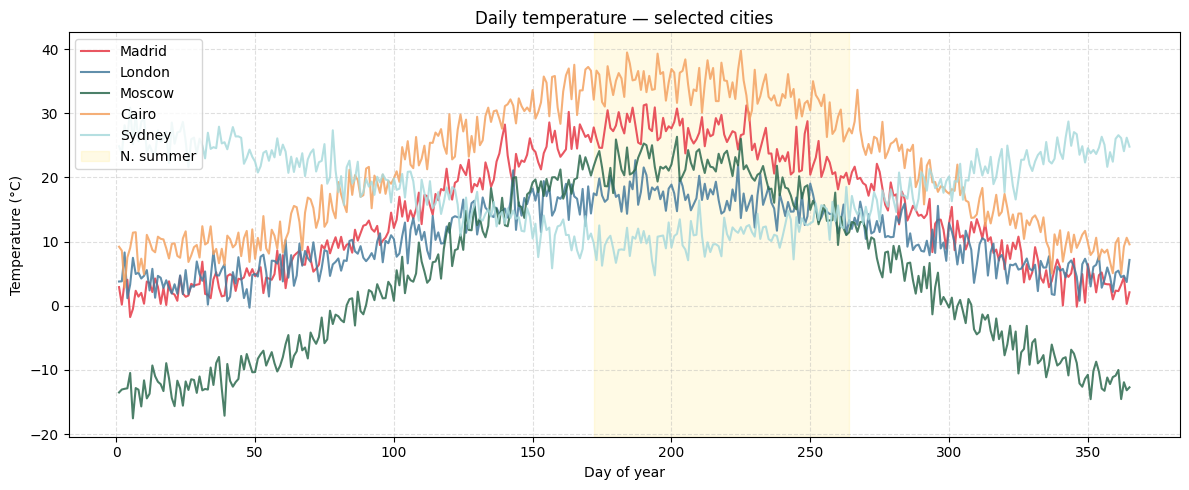

In [21]:
plot_cities = {
    "Madrid": "#e63946",
    "London": "#457b9d",
    "Moscow": "#2d6a4f",
    "Cairo": "#f4a261",
    "Sydney": "#a8dadc",
}

fig, ax = plt.subplots(figsize=(12, 5))

for city, color in plot_cities.items():
    v = climate.where(climate["city"] == city)
    d = v["day"].to_numpy().astype(int)
    t = v["temperature"].to_numpy()
    order = np.argsort(d)
    ax.plot(d[order], t[order], label=city, color=color, linewidth=1.5, alpha=0.85)

ax.axvspan(SUMMER_START, SUMMER_END, alpha=0.10, color="gold", label="N. summer")
ax.set_xlabel("Day of year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Daily temperature — selected cities")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 5.2 Summer temperature distribution — Madrid vs London

A simple histogram comparison of how often each city exceeds different temperature thresholds.

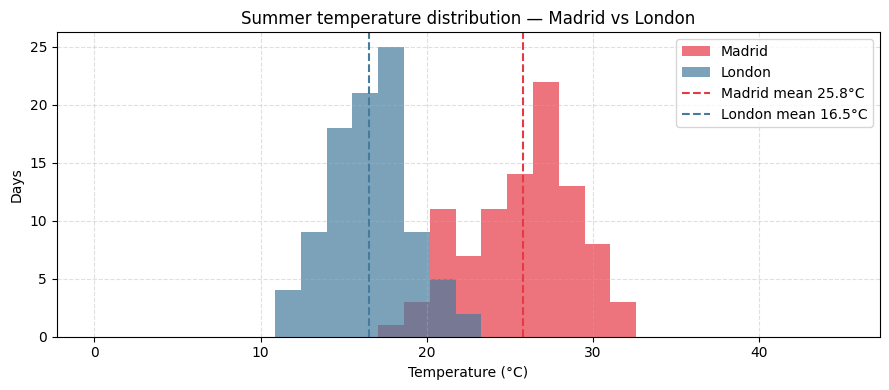

In [22]:
madrid_s = climate.where(
    (climate["city"] == "Madrid") & (climate["day"] >= SUMMER_START) & (climate["day"] <= SUMMER_END)
)["temperature"].to_numpy()

london_s = climate.where(
    (climate["city"] == "London") & (climate["day"] >= SUMMER_START) & (climate["day"] <= SUMMER_END)
)["temperature"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 45, 30)
ax.hist(madrid_s, bins=bins, alpha=0.7, color="#e63946", label="Madrid")
ax.hist(london_s, bins=bins, alpha=0.7, color="#457b9d", label="London")
ax.axvline(
    madrid_s.mean(),
    color="#e63946",
    linestyle="--",
    linewidth=1.5,
    label=f"Madrid mean {madrid_s.mean():.1f}°C",
)
ax.axvline(
    london_s.mean(),
    color="#457b9d",
    linestyle="--",
    linewidth=1.5,
    label=f"London mean {london_s.mean():.1f}°C",
)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Days")
ax.set_title("Summer temperature distribution — Madrid vs London")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 5.3 Mean summer temperature — all cities ranked

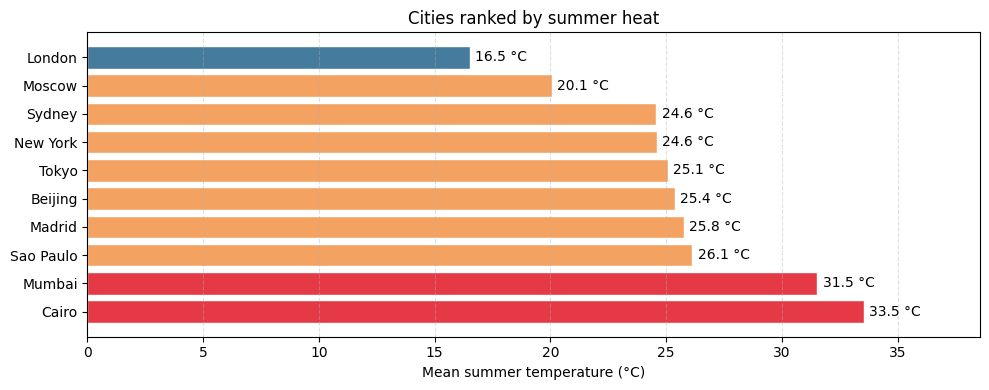

In [23]:
city_summer_means = {}
for city in CITY_PROFILES:
    v = climate.where(climate["city"] == city)
    if city == "Sydney" or city == "Sao Paulo":
        s = v.where((v["day"] <= 80) | (v["day"] >= 355))
    else:
        s = v.where((v["day"] >= SUMMER_START) & (v["day"] <= SUMMER_END))
    city_summer_means[city] = s["temperature"].mean()

sorted_cities = sorted(city_summer_means.items(), key=lambda x: x[1], reverse=True)
names = [c for c, _ in sorted_cities]
means = [m for _, m in sorted_cities]
colors = ["#e63946" if m > 30 else "#f4a261" if m > 20 else "#457b9d" for m in means]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(names, means, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f °C", padding=4)
ax.set_xlabel("Mean summer temperature (°C)")
ax.set_title("Cities ranked by summer heat")
ax.set_xlim(0, max(means) * 1.15)
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

---
## Part 6 — Mutations

CTable supports structural and value mutations: adding/dropping columns, deleting rows, sorting in place.

In [24]:
# Add a 'feels_like' column: temperature adjusted for wind chill (simplified)
climate.add_column("feels_like", blosc2.float32(), default=0.0)

temp = climate["temperature"].to_numpy()
wind = climate["wind_speed"].to_numpy()
# Simple wind-chill approximation (only meaningful below 10°C)
feels = np.where(temp < 10, temp - wind * 0.15, temp).astype(np.float32)
climate["feels_like"].assign(feels)

print("Table with feels_like column:")
print(climate.head(5))
print(f"\nColdest 'feels like' day: {climate['feels_like'].min():.1f} °C")

Table with feels_like column:
 city                day         temperature     humidity        wind_speed      pressure        feels_like   
 <U16                int16       float32         float32         float32         float32         float32      
──────────────────  ──────────  ──────────────  ──────────────  ──────────────  ──────────────  ──────────────
 Madrid              1           2.909233808517456    56.85164260864258    14.764506340026855    1014.2011108398438    0.6945576667785645 
 Madrid              2           0.17393270134925842    39.051292419433594    12.571674346923828    1017.43701171875    -1.7118185758590698 
 Madrid              3           3.712681531906128    38.422000885009766    12.351028442382812    1008.6416015625    1.8600271940231323 
 Madrid              4           4.054576396942139    46.61845016479492    14.6717529296875    1004.23876953125    1.8538134098052979 
 Madrid              5           -1.7631549835205078    51.75508117675781    18.27811

---
## Part 7 — Persistence

CTable can live on disk.  The on-disk layout is a directory with one `.b2nd` file per column  
plus a metadata frame — all still compressed.

In [25]:
import os
import shutil
import tempfile

tmpdir = tempfile.mkdtemp(prefix="blosc2_climate_")
disk_path = f"{tmpdir}/climate"

# Save the in-memory table to disk
climate.save(disk_path)
print(f"Saved to '{disk_path}'")

total_kb = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(disk_path) for f in fs) / 1024
print(f"On-disk size: {total_kb:.1f} KB")
print(f"In-memory compressed: {climate.cbytes / 1024:.1f} KB")

Saved to '/tmp/blosc2_climate_sjdvr9pf/climate'
On-disk size: 55.4 KB
In-memory compressed: 53.4 KB


In [26]:
# Open read-only — fast, no data is copied until you access a column
ro = CTable.open(disk_path)  # mode="r" by default
print(f"Opened read-only: {len(ro):,} rows")
print(f"Cairo annual mean: {ro.where(ro['city'] == 'Cairo')['temperature'].mean():.1f} °C")

# Load fully into RAM (useful when you need repeated random access)
ram = CTable.load(disk_path)
print(f"Loaded into RAM : {len(ram):,} rows")

shutil.rmtree(tmpdir)
print("Temporary files removed.")

Opened read-only: 3,650 rows
Cairo annual mean: 21.9 °C
Loaded into RAM : 3,650 rows
Temporary files removed.


---
## Part 8 — Arrow & CSV interop

CTable speaks Arrow and CSV, so it fits naturally into data pipelines.

In [27]:
# CTable → Arrow
arrow_table = climate.select(["city", "day", "temperature"]).to_arrow()
print("Arrow table schema:", arrow_table.schema)
print("First 3 rows:", arrow_table.slice(0, 3).to_pydict())

Arrow table schema: city: string
day: int16
temperature: float
First 3 rows: {'city': ['Madrid', 'Madrid', 'Madrid'], 'day': [1, 2, 3], 'temperature': [2.909233808517456, 0.17393270134925842, 3.712681531906128]}


In [28]:
import os
import tempfile

# CTable → CSV → CTable round-trip
tmp_csv = tempfile.mktemp(suffix=".csv")
climate.select(["city", "day", "temperature", "humidity"]).to_csv(tmp_csv)

print(f"CSV size: {os.path.getsize(tmp_csv) / 1024:.1f} KB")


@dataclass
class SlimReading:
    city: str = blosc2.field(blosc2.string(max_length=16))
    day: int = blosc2.field(blosc2.int16(ge=1, le=365), default=1)
    temperature: float = blosc2.field(blosc2.float32(), default=0.0)
    humidity: float = blosc2.field(blosc2.float32(), default=0.0)


t_from_csv = CTable.from_csv(tmp_csv, SlimReading)
print(f"Loaded from CSV: {len(t_from_csv):,} rows")
os.remove(tmp_csv)

CSV size: 111.5 KB
Loaded from CSV: 3,650 rows


---
## Summary

Here's everything we covered:

| Feature | API |
|---------|-----|
| Create | `CTable(Schema)`, `CTable(Schema, new_data=...)` |
| Insert | `append(row)`, `extend(list_or_array)` |
| View | `head()`, `tail()`, `print(t)`, `t.info()` |
| Filter | `where(expr)` → view |
| Project | `select([cols])` → view |
| Sort | `sort_by(cols)`, `sort_by(cols, inplace=True)` |
| Aggregates | `col.sum()`, `.mean()`, `.std()`, `.min()`, `.max()` |
| Stats | `describe()`, `cov()` |
| Mutate | `delete()`, `compact()`, `add_column()`, `drop_column()`, `assign()` |
| Persist | `save(path)`, `CTable.open(path)`, `CTable.load(path)` |
| Interop | `to_arrow()`, `from_arrow()`, `to_csv()`, `from_csv()` |

CTable is designed for **compressed analytical workloads** — large tables that need to stay small in RAM  
while still being fast to query and easy to persist.